In [3]:
import pickle
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from neural_network import NeuralNetwork
from sklearn.datasets import load_digits
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from util import plot_explanations

# Tests for Evaluating Explanations

In this analysis, you will be conducting 2 tests of the 3 neural network explanations you implemented for the checkpoint.  You will be conducting both tests on the MNIST dataset, however the first test will be on a large version of the dataset (each image is 28x28 pixels) and the second test will be a small version, like in the validate model notebook, where each image is 8x8 pixels.

After conducting these 2 tests, you will design, describe and implement your own test as the final step of this project.

The inspiration for this analysis is from the paper "Sanity Checks for Saliency Maps" by Adebayo et al.  I encourage you to browse through this paper at some point while you are working on this project.  

Paper link: https://proceedings.neurips.cc/paper_files/paper/2018/file/294a8ed24b1ad22ec2e7efea049b8737-Paper.pdf 

# Step 1: Explore a Pre-trained model on Large MNIST

## Move useful functions into util.py

Put your function for showing the 4 different explanations into util.py  Write a second function for evaluating a multiclass model.  You can compute an AUC score by averaging the AUC across classes, or you can skip computing the AUC score in the multiclass case.

## Load in the fit MNIST Model and Larger Dataset

Load the data from fit_mnist_model.p using pickle.

### There is a dictionary titled 'data' inside that has the following:

1. X, where each row is a single instance.  The features correspond to each pixel in a handwritten image of a digit unrolled into a feature vector.  This is a 28x28 image instead of the 8x8 images in the validation notebook.  The features have already been min-max scaled to be between 0 and 1. 

2. y, the class labels for each instance as a 1-D array.  The class is the value of the handwritten digit shown in the image.

3. onehot_y: the class labels for each instances as a onehot encoding of y.  

4. train_indices and test_indices: Your data has already been split into train and test sets.  If you'd like to make a validation set for anything, you should make it from your train set.

### There is a dictionary titled 'model' that has the following:

1. Weights, a list of the weights for each layer.

2. Biases, a list of the biases for each layer.  


NOTE: You will need to make a NeuralNetwork model using your implementation and load in the supplied parameters to do the following steps.  You could approach this by making a new method in your NN class to allow you to load in parameters, but it's your choice how you want to do this.

In [2]:
data_dict = pickle.load(open( 'fit_mnist_model.p', 'rb'))

data = data_dict['data'] 
model = data_dict['model']

X_train = data['X'][data['train_indices']]
y_train = data['y'][data['train_indices']]
X_test = data['X'][data['test_indices']]
y_test = data['y'][data['test_indices']]

## Print model evaluation and explanations for this model

Use your functions from util to evaluate the model and to visualize the image and 3 explanations of a random test datapoint.  You should only visualize instances with a predicted probability for the predicted class below 0.90   This is because the explanations will tend to be more interesting for this analysis when the model is not highly certain of its prediction.  

You should be able to run the cell below multiple times and have it explain a different test instance each time.

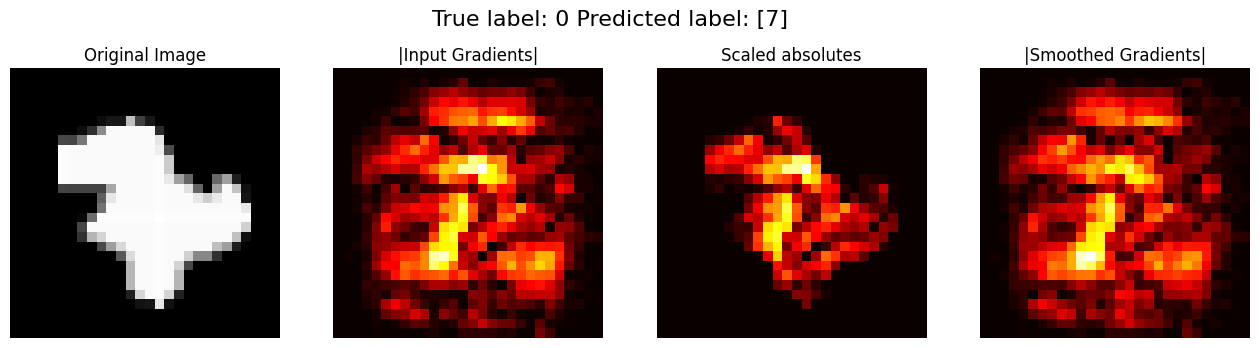

In [3]:
NN = NeuralNetwork(n_features=784, n_classes=10, layer_sizes=[784, 128, 10])
NN.load_parameters(model)

plot_explanations([NN], X_test, y_test, model_names=["Model"])

## Generate 3 new versions of this model with 1 or more layers randomized

Make 3 new neural networks and copy over the parameters from fit_mnist_model.p for all 3 models.  For random_model_1, replace the weights at the last layer (the one furthest from the inputs and closest to the predictions) with randomly sampled weights with the same shape.  Sample the weights in the same way you initialize them in your neural network implementation.  For random_model_2, randomize the last 2 layers (everything except the layer closest to the inputs), and for random_model_3, randomize all 3 layers.  

Use your model evaluation function to print the performance of each model.  You should see that the original model remains the same, and all of the randomized models should be quite bad.

In [4]:
def create_random_models(model):
    original_model = NeuralNetwork(n_features=784, n_classes=10, layer_sizes=[784, 128, 10])
    original_model.load_parameters(model)
    
    #create random models and get their parameters
    ranModel_one = NeuralNetwork(n_features=784, n_classes=10, layer_sizes=[784, 128, 10])
    ranModel_two = NeuralNetwork(n_features=784, n_classes=10, layer_sizes=[784, 128, 10])
    ranModel_three = NeuralNetwork(n_features=784, n_classes=10, layer_sizes=[784, 128, 10])
    ranModel_one.load_parameters(model)
    ranModel_two.load_parameters(model)
    ranModel_three.load_parameters(model)
    
    ranModel_one.randomized_layer(-1)
    ranModel_two.randomized_layer(-1)
    ranModel_two.randomized_layer(-2)
    ranModel_three.randomized_layer(0)
    ranModel_three.randomized_layer(1) 
    
    return original_model, ranModel_one, ranModel_two, ranModel_three

## Show explanations for all 4 models (the original and the 3 randomized ones)

Use your functions from util to evaluate the model and to visualize the image and 3 explanations of a random test datapoint for all 4 models (the original and the 3 randomized ones).  Make sure to label your explanations so it is clear which model they belong to.  You should only visualize instances with a predicted probability for the predicted class below 0.90   This is because the explanations will tend to be more interesting for this analysis when the model is not highly certain of its prediction.  

You should be able to run the cell below multiple times and have it explain a different test instance each time.

Explore explanations of different random test instances until you feel like you can answer the writing prompt below.


Original Model:
Accuracy:  96.82%
Random Model One:
Accuracy:  24.44%
Random Model Two:
Accuracy:  5.96%
Random Model Three:
Accuracy:  10.71%


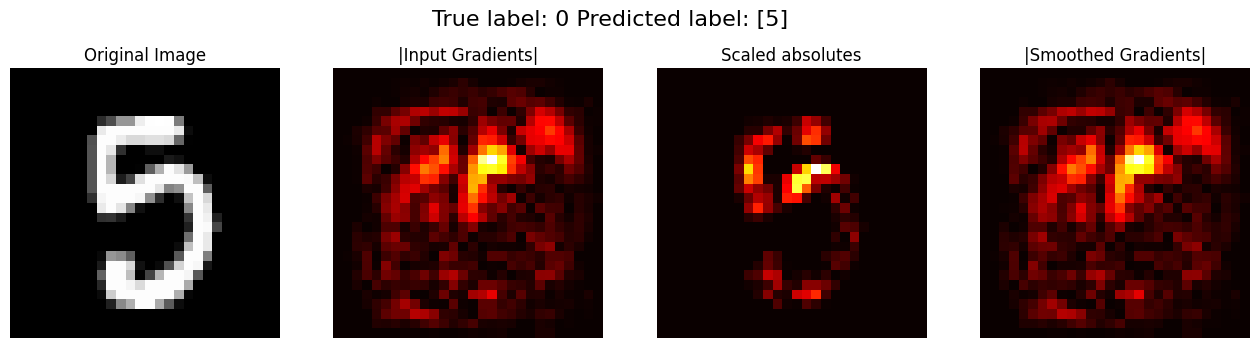

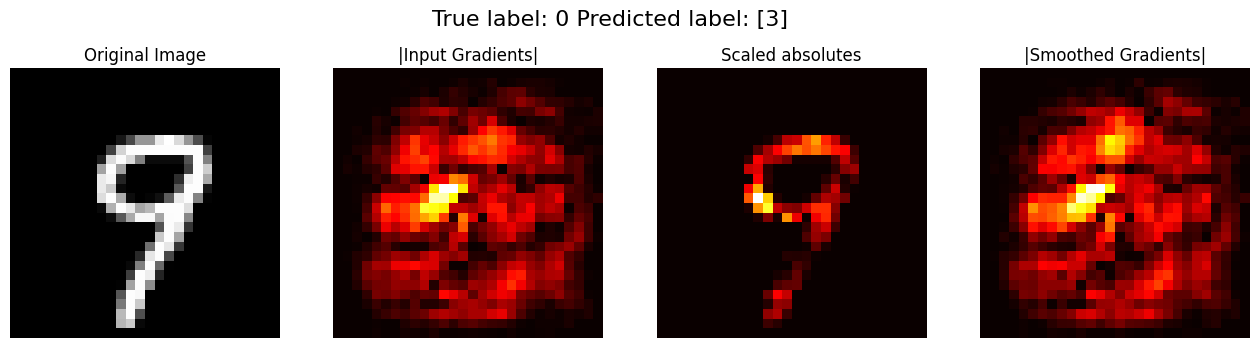

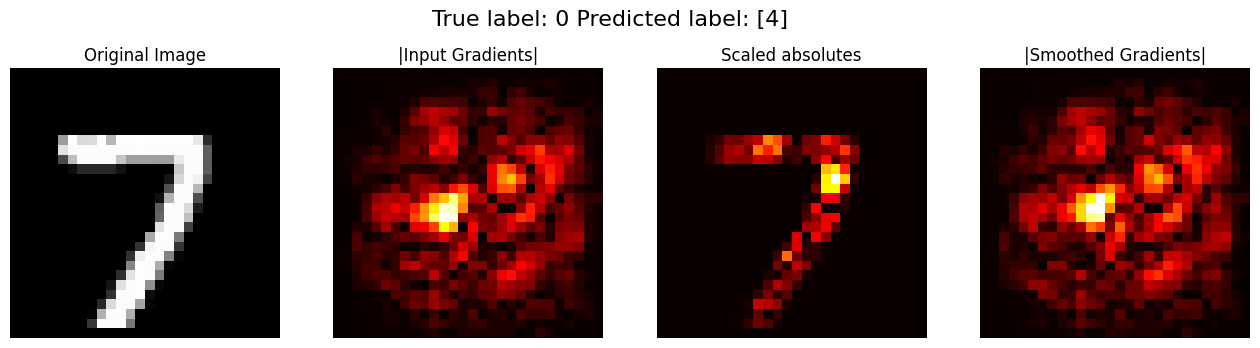

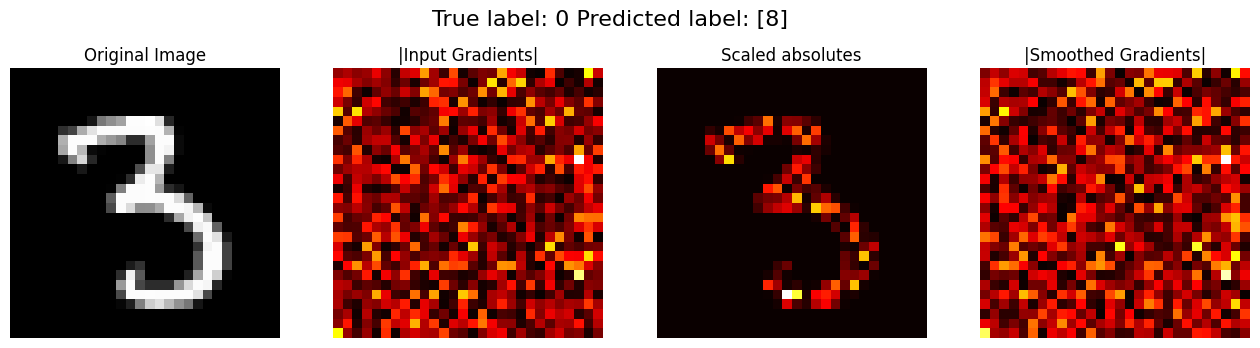

In [ ]:
original_model, ranModel_one, ranModel_two, ranModel_three = create_random_models(model)

#eval original model
print("Original Model:")
original_model.evaluate(X_test, y_test)

#eval model 1
print("Random Model One:")
ranModel_one.evaluate(X_test, y_test)

#eval model 2
print("Random Model Two:")
ranModel_two.evaluate(X_test, y_test)

#eval model 3
print("Random Model Three:")
ranModel_three.evaluate(X_test, y_test)

model_names = ["Original Model", "Random Model One", "Random Model Two", "Random Model Three"]
model_type= [original_model, ranModel_one, ranModel_two, ranModel_three]


plot_explanations(model_type, X_test, y_test, model_names)



## Writing Prompt 1: Evaluating Explanations with randomized weights

Based on this experiment where we randomized the weights of a model, which explanations are good?  Which ones aren't?  Explain how you can tell based on your results here.  This should be around 2-5 sentences.

Starting with the numerical data we can see that the original model does quite a good job at deciding the label of the image from using the features of the image. The input gradients highlight the important regions and the smooth gradients identify the signifcant features. The first two random models are less focused making the gradients blur, likely because the weight randomization hinders the model from identifying the important patterns that appear in the image. In the last random model eventhough it has a higher accuracy than model two its explanation is the most chaotic and insignificant. It shows not clear patterns or consistency to the input image. 

# Step 2: Train your own model on Small MNIST

## Load in small mnist

Load in the small version of MNIST by using scikit-learn's load_digits() method (https://scikit-learn.org/0.15/modules/generated/sklearn.datasets.load_digits.html).  You will find an 'images' attribute that holds the features, a 'target' attribute that holds the labels, and a 'feature_names' attribute that holds the feature names (although you may not need this).  The images are matrices of size 28x28 where each entry corresponds to a pixel value.  You should reshape them so that each image is represented by a 1-d array.  I.e. X should be an array of size Nx784.  

You should then do the following preprocessing:

1. Scale X using a MinMaxScaler (this scales the data to be in the 0-1 range rather than scaling to be centered around 0)
2. Onehot encode y.  You should keep both the original y and onehot_y.  Different methods will need y in different formats.
3. Generate a train and test split

In [7]:
from sklearn.datasets import load_digits
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.model_selection import train_test_split

digits = load_digits()
X = digits.images
y = digits.target

X = X.reshape((X.shape[0], -1))
print(f"features: {X.shape}")
print(f"labels: {y.shape}")

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
encoder = OneHotEncoder(sparse_output=False)
y_onehot = encoder.fit_transform(y.reshape(-1, 1))
print(f"y- onehot shape: {y_onehot.shape}")

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_onehot, test_size=0.2, random_state=7)
print(f"Train shape: {X_train.shape}, {y_train.shape}")
print(f"Test shape: {X_test.shape}, {y_test.shape}")


features: (1797, 64)
labels: (1797,)
y- onehot shape: (1797, 10)
Train shape: (1437, 64), (1437, 10)
Test shape: (360, 64), (360, 10)


## Train your neural network on small mnist and evaluate it

Train your neural network implementation on the train set.  You should have 3 hidden layers of size 250, 100 and 50 respectively.  You should train your model for 5000 iterations, and use an alpha of 1.  You can use the default values of other parameters. 

Evaluate your model using your function from util.py

In [8]:
NN= NeuralNetwork(n_features=64, n_classes=10, layer_sizes=[64, 250, 100, 50, 10], n_iter=5000, step_size= 1e-2, batch_size=64, alpha=1)

NN.fit(X_train, y_train)

accuracy = NN.evaluate(X_test, y_test)
print(f"Test accuracy: {accuracy:.2f}")

Accuracy:  7.78%
Test accuracy: 0.08


## Generate a set of random labels and use them to train and evaluate a second model

Generate a set of random labels, random_y by permuting the class labels in y (you can approach this by shuffling y).  Make sure to generate a corresponding random_onehot_y. 

Train a second random_neural_network with the same paramaters used above, but using the random labels you just generated.

Evaluate your model using your function in util.py 

Your model should still do quite well on the train set.  It may do worse on the test set.

In [9]:

ran_onehot_y = np.copy(y_train) 
np.random.shuffle(ran_onehot_y) 

ran_NN = NeuralNetwork(n_features=64, n_classes=10, layer_sizes=[64, 250, 100, 50, 10], n_iter=5000, step_size=1e-2, batch_size=64, alpha=1)
ran_NN.fit(X_train, ran_onehot_y)

random_labels = np.argmax(ran_onehot_y, axis=1)

train_accuracy_random = ran_NN.evaluate(X_train, random_labels)
print(f"Training accuracy w/ random labeling: {train_accuracy_random:.2f}")

test_accuracy_random = ran_NN.evaluate(X_test, y_test)
print(f"Test accuracy w/ random labeling: {test_accuracy_random:.2f}")

Accuracy:  10.72%
Training accuracy w/ random labeling: 0.11
Accuracy:  7.78%
Test accuracy w/ random labeling: 0.08


## Show explanations for both models (the original and the one with random labels)

Use your functions from util to evaluate the model and to visualize the image and 3 explanations of a random test datapoint for both models (the original and the one with randomized labels).  Make sure to label your explanations so it is clear which model they belong to.  You should only visualize instances with a predicted probability for the predicted class below 0.90   This is because the explanations will tend to be more interesting for this analysis when the model is not highly certain of its prediction.  

You should be able to run the cell below multiple times and have it explain a different test instance each time.

Explore explanations of different random test instances until you feel like you can answer the writing prompt below.

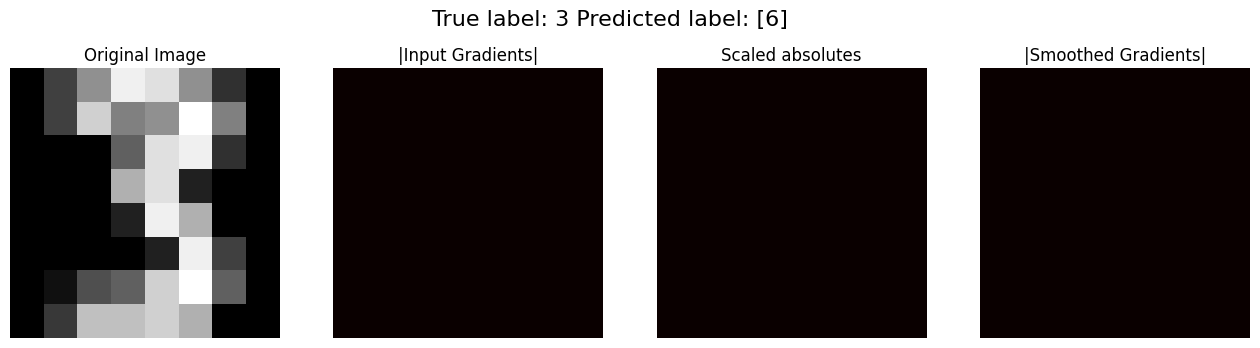

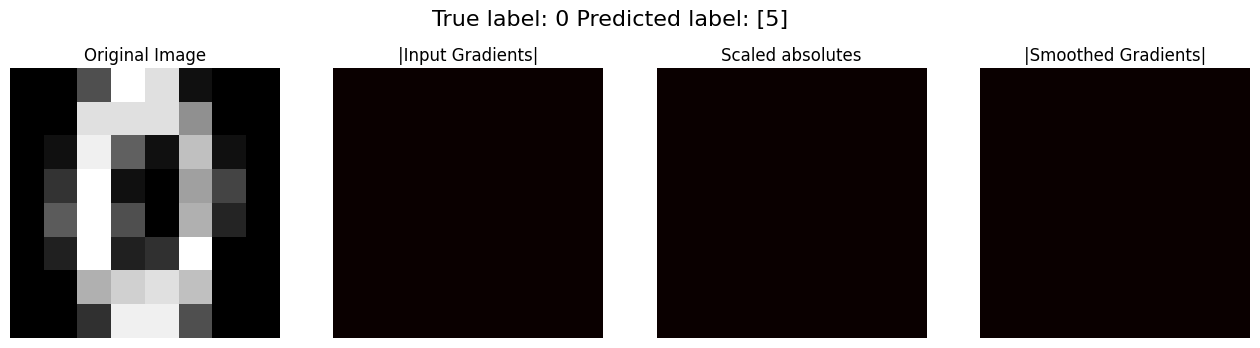

In [11]:
model_title = ["Original Model", "Random label Model"]
plot_explanations([NN, ran_NN], X_test, y_test, model_names= model_title)

## Writing Prompt 2: Evaluating Explanations with randomized labels

Based on this experiment where we randomized the labels then trained a model, which explanations are good?  Which ones aren't?  Explain how you can tell based on your results here.  This should be around 2-5 sentences.

The explanations from the original model are better you can see from the explanation that the model is able to find some patterns and identify distinct regions. In the random leabeled model that we trained, the explanations are blank. This suggests that the model is significantly deficit, it can't find key features or provide viewable gradients. 

# Step 3: Design and conduct your own test of the 3 explanation methods

The third step of this assigment is to design, implement and evaluate your own test of the neural network explanation methods we implemented in this project.  You should be able to argue that, based on the results of your test, you can tell whether and explanation provides useful information.  The test doesn't need to fully work as expected, but you should be able to make a good argument for why it is a reasonable approach to testing an explanation method.  

For example, in both of the tests above, we have a test case that should produce a good explanation and one that should produce a nonsense explanation (random weights or random labels for training).  We then checked whether the explanations for the nonsense cases differed from the good cases.  

For your test, here are a few options:
1. You can devise another way of training a nonsense model and compare its explanations to the good model
2. You can modify instances based on the features an explanation claims are influencing the prediction and check whether the prediction changes
3. You can develop an approach to synthesizing the results from the 2 tests we studied to summarize them across the entire dataset (currently, we are only able to look at explanations for 1 instances at a time).
4. Any other reasonable idea you have!

A complete version of step 3 will include:

In this notebook
1. An implementation of your test
2. The results of running your test on one of the datasets we studied

In a written project report:

3. A high level description of the test that explains how it works and why it should allow us to differentiate "good" and "bad" explanations.
4. A detailed description of your implementation of the test that would allow me to replicate it
5. A results section with a representative figure for all 3 of the tests in this notebook and corresponding written analysis of the results
6. A synthesis of your results from all 3 tests explaining arguing in defense of the "best" explanation of the 3 we studied.  As usual, you are welcome and encouraged to point out downsides of the best explanation method, but you should still choose 1 to defend.
7. A brief reflection on the strengths and limitations of the 3 tests we studied.

You will find a detailed outline for the project report in the "Project 3 - Testing Neural Network Explanations - Writing Assignment" file explaining exactly what each section should include.  You can expect it to be fairly similar to a proejct report you wrote for CS15X or CS231.


## Writing Prompt 3: Describing your test

What is your test and why should it allow us to differentiate good and bad explanations?  This is a short explanation to give me enough context to evaluate your code.  You should include a more detailed explanation in your report.  This should be around 2-5 sentences.

My test uses the fashion MNIST data to generate explanations then I compare it to the explanations generated by the same network after I mix up the input features. We hope to compare good explanations with bad explanations by generating bad explanations and comparing them to the original model. 

In [8]:
import pandas as pd
import numpy as np
from neural_network import NeuralNetwork
from util import plot_explanations
from sklearn.preprocessing import OneHotEncoder


train = pd.read_csv('fashion-mnist_train.csv') 
test = pd.read_csv('fashion-mnist_test.csv') 

X_train = train.iloc[:, 1:].values
y_train = train.iloc[:, 0].values
X_test = test.iloc[:, 1:].values 
y_test = test.iloc[:, 0].values


X_train = X_train/ 255.0
X_test = X_test/ 255.0
encoder = OneHotEncoder(sparse_output=False)
y_train_onehot = encoder.fit_transform(y_train.reshape(-1, 1))
y_test_onehot = encoder.transform(y_test.reshape(-1, 1))

#original data
original_model_NN = NeuralNetwork(n_features=784, n_classes=10, layer_sizes=[784, 512, 256, 128, 10], step_size=1e-3, n_iter=5000, batch_size=64, alpha=0.01)
original_model_NN.fit(X_train, y_train_onehot)

test_accuracy = original_model_NN.evaluate(X_test, y_test_onehot)
print(f"Test accuracy on Fashion MNIST using original training data: {test_accuracy:.2f}")

Accuracy:  10.00%
Test accuracy on Fashion MNIST using original training data: 0.10


In [ ]:
#shuffled data
X_train_shuffled = np.copy(X_train)
np.random.shuffle(X_train_shuffled)


shuffled_model_NN = NeuralNetwork(n_features=784, n_classes=10, layer_sizes=[784, 512, 256, 128, 10], step_size=1.e-3, n_iter=5000, batch_size=64, alpha=0.01)
shuffled_model_NN.fit(X_train_shuffled, y_train_onehot)

test_accuracy = shuffled_model_NN.evaluate(X_test, y_test_onehot)
print(f"Test accuracy on Fashion MNIST using shuffled training data: {test_accuracy:.2f}")

Accuracy:  10.00%
Test accuracy on Fashion MNIST using shuffled training data: 0.10


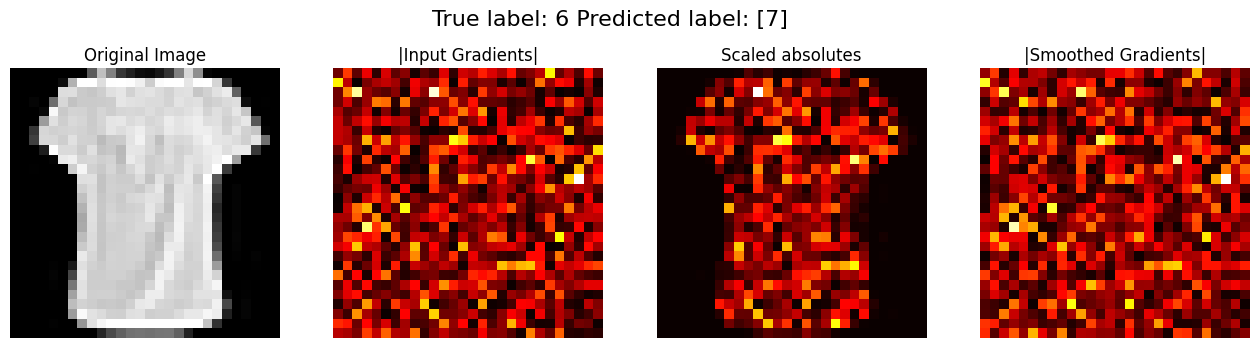

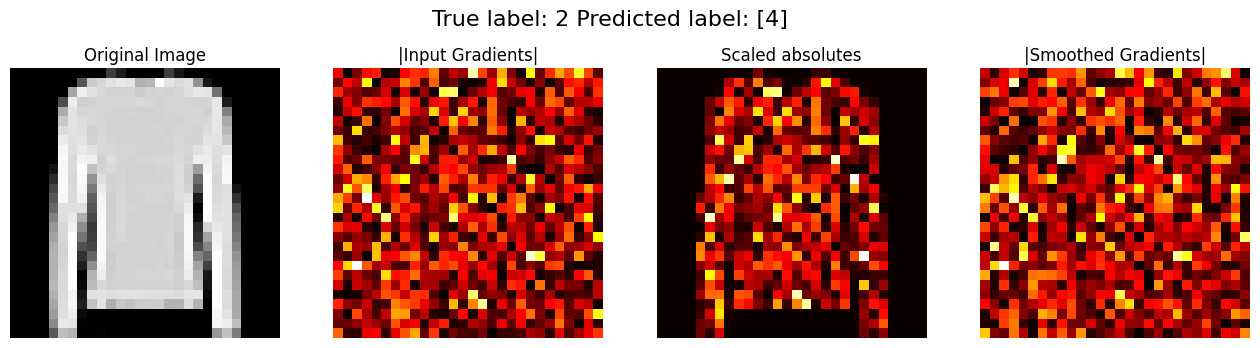

[[array([2.53643523e-10, 7.60743801e-10, 2.16908241e-10, 5.70293146e-10,
         8.70292449e-11, 5.25507193e-10, 2.14221058e-10, 3.22151777e-10,
         3.75318110e-11, 2.06201112e-10, 1.22609894e-10, 5.38493472e-10,
         9.36818539e-11, 4.95658903e-10, 4.38363429e-10, 6.89483415e-10,
         5.28711186e-10, 4.04093259e-10, 6.55568488e-10, 2.33764730e-10,
         2.97704916e-10, 4.47453657e-10, 1.25233501e-09, 2.26372976e-10,
         4.19165175e-10, 1.71126738e-10, 6.52240373e-10, 2.48175869e-10,
         1.23200949e-09, 4.51136878e-10, 3.31873418e-13, 2.81600521e-10,
         4.05838446e-10, 4.63451999e-10, 3.81362580e-10, 1.51463120e-10,
         5.84605697e-10, 4.20091933e-10, 3.75371789e-10, 7.25633553e-10,
         1.26118282e-11, 6.89449942e-10, 2.28700933e-10, 3.03885500e-10,
         3.00625191e-10, 4.89291940e-11, 2.01945322e-10, 1.23955846e-11,
         1.99297745e-10, 8.90689689e-10, 3.54414109e-10, 6.40121955e-10,
         5.70534897e-10, 6.83952478e-11, 3.84587168

In [ ]:
#generate explanations
from util import plot_explanations
names= ["Original Model", "Shuffled Model"]
model_type= [original_model_NN, shuffled_model_NN]
plot_explanations(model_type, X_test, y_test_onehot, names)



## Writing Prompt 4: Evaluating Explanations with your test

Based on this experiment you designed, which explanations are good?  Which ones aren't?  Explain how you can tell based on your results here.  This should be around 2-5 sentences.

Based on this experiment it appears that both explanations are bad. If you look at both of the model explanations the models aren't able to identify the significant features or regions of importance. The explanations are grainy and unclear. The scaled absolutes do a good job but this is expected because its just a matter of emphasizing the area with the most importance to the image. It is quite obvious that the area with the most importance is the area that depicts the clothing item.  

Overall, this is a bit of a surprising result, it suggests that there might be an issue with the training that is occuring on the model or that the hyperparamters are underfitting the data at the same rate. I am not sure what is going on here.